In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.calibration import CalibratedClassifierCV

from xgboost import XGBClassifier

warnings.filterwarnings(
    "ignore"
)

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


In [2]:
# ============================================================
# CELL 2: PROJECT PATHS
# ============================================================

from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\bimal\OneDrive\Desktop\bibhu sir project"
    r"\question_similarity_project"
)

MODEL_DIR = (
    PROJECT_ROOT
    / "model"
)

FEATURE_DIR = (
    MODEL_DIR
    / "feature_artifacts"
)

FEATURE_PATH = (
    FEATURE_DIR
    / "engineered_features.pkl"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:")
print(PROJECT_ROOT)

print("\nModel directory:")
print(MODEL_DIR)

print("\nFeature directory:")
print(FEATURE_DIR)

print("\nFeature file:")
print(FEATURE_PATH)

Project root:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project

Model directory:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model

Feature directory:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model\feature_artifacts

Feature file:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model\feature_artifacts\engineered_features.pkl


In [3]:
# ============================================================
# CELL 3: CHECK ENGINEERED FEATURE FILE
# ============================================================

print("=" * 70)
print("CHECKING FEATURE ARTIFACT")
print("=" * 70)

print("\nExpected location:")
print(FEATURE_PATH)

print(
    "\nExists:",
    FEATURE_PATH.exists()
)


if not FEATURE_PATH.exists():

    print("\n❌ FILE NOT FOUND")
    print(
        "\nThe training notebook cannot continue because "
        "engineered_features.pkl has not been created."
    )

    print(
        "\nGo to:"
    )

    print(
        "3_Feature_engineering.ipynb"
    )

    print(
        "\nRun its final SAVE cell first."
    )

    raise FileNotFoundError(
        f"\nMissing:\n{FEATURE_PATH}"
    )


print(
    "\n✓ engineered_features.pkl found."
)

print(
    "File size:",
    f"{FEATURE_PATH.stat().st_size / (1024**2):.2f} MB"
)

CHECKING FEATURE ARTIFACT

Expected location:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model\feature_artifacts\engineered_features.pkl

Exists: True

✓ engineered_features.pkl found.
File size: 24.64 MB


In [4]:
# ============================================================
# CELL 4: LOAD ENGINEERED FEATURES
# ============================================================

with open(
    FEATURE_PATH,
    "rb"
) as file:

    feature_data = pickle.load(
        file
    )


print("✓ Engineered feature artifact loaded.")

print("\nAvailable keys:")

for key in feature_data.keys():

    print(
        " -",
        key
    )

✓ Engineered feature artifact loaded.

Available keys:
 - hand_train
 - hand_val
 - hand_test
 - y_train
 - y_val
 - y_test
 - feature_names
 - n_features


In [5]:
# ============================================================
# CELL 5: EXTRACT FEATURES
# ============================================================

X_train = feature_data[
    "hand_train"
]

X_val = feature_data[
    "hand_val"
]

X_test = feature_data[
    "hand_test"
]

y_train = feature_data[
    "y_train"
]

y_val = feature_data[
    "y_val"
]

y_test = feature_data[
    "y_test"
]

feature_names = feature_data[
    "feature_names"
]


print("✓ Features extracted.")

print(
    "\nX_train:",
    X_train.shape
)

print(
    "X_val:",
    X_val.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "\ny_train:",
    y_train.shape
)

print(
    "y_val:",
    y_val.shape
)

print(
    "y_test:",
    y_test.shape
)

✓ Features extracted.

X_train: (271524, 15)
X_val: (76226, 15)
X_test: (55986, 15)

y_train: (271524,)
y_val: (76226,)
y_test: (55986,)


In [6]:
# ============================================================
# CELL 6: CONVERT DATA TYPES
# ============================================================

X_train = np.asarray(
    X_train,
    dtype=np.float32
)

X_val = np.asarray(
    X_val,
    dtype=np.float32
)

X_test = np.asarray(
    X_test,
    dtype=np.float32
)

y_train = np.asarray(
    y_train,
    dtype=np.int32
)

y_val = np.asarray(
    y_val,
    dtype=np.int32
)

y_test = np.asarray(
    y_test,
    dtype=np.int32
)

print("✓ Data converted to NumPy.")

✓ Data converted to NumPy.


In [7]:
# ============================================================
# CELL 7: VALIDATE FEATURE DIMENSIONS
# ============================================================

n_features = X_train.shape[1]

print(
    "Number of features:",
    n_features
)

if X_val.shape[1] != n_features:

    raise RuntimeError(
        "Validation feature count does not "
        "match training feature count."
    )

if X_test.shape[1] != n_features:

    raise RuntimeError(
        "Test feature count does not "
        "match training feature count."
    )

if len(feature_names) != n_features:

    raise RuntimeError(
        "Feature names count does not match "
        "feature count."
    )

print(
    "\n✓ Feature dimensions are valid."
)

Number of features: 15

✓ Feature dimensions are valid.


In [8]:
# ============================================================
# CELL 8: CHECK NAN / INFINITY
# ============================================================

for name, data in [
    ("X_train", X_train),
    ("X_val", X_val),
    ("X_test", X_test)
]:

    nan_count = np.isnan(
        data
    ).sum()

    inf_count = np.isinf(
        data
    ).sum()

    print(
        f"{name}: "
        f"NaN={nan_count}, "
        f"Inf={inf_count}"
    )

    if nan_count > 0:

        raise RuntimeError(
            f"NaN values found in {name}."
        )

    if inf_count > 0:

        raise RuntimeError(
            f"Infinite values found in {name}."
        )

print(
    "\n✓ Feature matrices are clean."
)

X_train: NaN=0, Inf=0
X_val: NaN=0, Inf=0
X_test: NaN=0, Inf=0

✓ Feature matrices are clean.


In [9]:
# ============================================================
# CELL 9: CLASS DISTRIBUTION
# ============================================================

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

for name, labels in [
    ("TRAIN", y_train),
    ("VALIDATION", y_val),
    ("TEST", y_test)
]:

    print(
        f"\n{name}"
    )

    counts = pd.Series(
        labels
    ).value_counts(
        normalize=False
    ).sort_index()

    for label, count in counts.items():

        percentage = (
            count /
            len(labels)
        ) * 100

        print(
            f"Class {label}: "
            f"{count:,} "
            f"({percentage:.2f}%)"
        )

CLASS DISTRIBUTION

TRAIN
Class 0: 172,450 (63.51%)
Class 1: 99,074 (36.49%)

VALIDATION
Class 0: 45,835 (60.13%)
Class 1: 30,391 (39.87%)

TEST
Class 0: 36,699 (65.55%)
Class 1: 19,287 (34.45%)


In [10]:
# ============================================================
# CELL 10: CLASS WEIGHT
# ============================================================

negative_count = np.sum(
    y_train == 0
)

positive_count = np.sum(
    y_train == 1
)

if positive_count == 0:

    raise RuntimeError(
        "No positive samples found."
    )

scale_pos_weight = (
    negative_count /
    positive_count
)

print(
    "Negative:",
    negative_count
)

print(
    "Positive:",
    positive_count
)

print(
    "Scale positive weight:",
    round(
        scale_pos_weight,
        4
    )
)

Negative: 172450
Positive: 99074
Scale positive weight: 1.7406


In [11]:
# ============================================================
# CELL 11: CREATE XGBOOST MODEL
# ============================================================

model = XGBClassifier(

    n_estimators=700,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.85,

    colsample_bytree=0.85,

    min_child_weight=3,

    gamma=0.1,

    reg_alpha=0.1,

    reg_lambda=1.0,

    objective="binary:logistic",

    eval_metric="logloss",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)

print(
    "✓ XGBoost model created."
)

✓ XGBoost model created.


In [12]:
# ============================================================
# CELL 12: TRAIN MODEL
# ============================================================

print("=" * 70)
print("TRAINING QUESTION SIMILARITY MODEL")
print("=" * 70)

model.fit(

    X_train,

    y_train,

    eval_set=[
        (
            X_val,
            y_val
        )
    ],

    verbose=True
)

print(
    "\n✓ Model training completed."
)

TRAINING QUESTION SIMILARITY MODEL
[0]	validation_0-logloss:0.68125
[1]	validation_0-logloss:0.66987
[2]	validation_0-logloss:0.65954
[3]	validation_0-logloss:0.65067
[4]	validation_0-logloss:0.64196
[5]	validation_0-logloss:0.63411
[6]	validation_0-logloss:0.62675
[7]	validation_0-logloss:0.62006
[8]	validation_0-logloss:0.61413
[9]	validation_0-logloss:0.60837
[10]	validation_0-logloss:0.60299
[11]	validation_0-logloss:0.59831
[12]	validation_0-logloss:0.59397
[13]	validation_0-logloss:0.58981
[14]	validation_0-logloss:0.58576
[15]	validation_0-logloss:0.58231
[16]	validation_0-logloss:0.57916
[17]	validation_0-logloss:0.57614
[18]	validation_0-logloss:0.57336
[19]	validation_0-logloss:0.57068
[20]	validation_0-logloss:0.56807
[21]	validation_0-logloss:0.56571
[22]	validation_0-logloss:0.56339
[23]	validation_0-logloss:0.56109
[24]	validation_0-logloss:0.55920
[25]	validation_0-logloss:0.55743
[26]	validation_0-logloss:0.55578
[27]	validation_0-logloss:0.55419
[28]	validation_0-loglo

In [13]:
# ============================================================
# CELL 13: VALIDATION PREDICTION
# ============================================================

val_probability = model.predict_proba(
    X_val
)[:, 1]

val_prediction = (
    val_probability >= 0.50
).astype(int)

print(
    "✓ Validation prediction completed."
)

✓ Validation prediction completed.


In [14]:
# ============================================================
# CELL 14: VALIDATION METRICS
# ============================================================

val_accuracy = accuracy_score(
    y_val,
    val_prediction
)

val_precision = precision_score(
    y_val,
    val_prediction,
    zero_division=0
)

val_recall = recall_score(
    y_val,
    val_prediction,
    zero_division=0
)

val_f1 = f1_score(
    y_val,
    val_prediction,
    zero_division=0
)

val_auc = roc_auc_score(
    y_val,
    val_probability
)

print("=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print(
    f"Accuracy : {val_accuracy:.4f}"
)

print(
    f"Precision: {val_precision:.4f}"
)

print(
    f"Recall   : {val_recall:.4f}"
)

print(
    f"F1 Score : {val_f1:.4f}"
)

print(
    f"ROC-AUC  : {val_auc:.4f}"
)

VALIDATION RESULTS
Accuracy : 0.7132
Precision: 0.6039
Recall   : 0.8158
F1 Score : 0.6941
ROC-AUC  : 0.8002


In [15]:
# ============================================================
# CELL 15: CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(

        y_val,

        val_prediction,

        target_names=[
            "Not Duplicate",
            "Duplicate"
        ],

        zero_division=0
    )
)

               precision    recall  f1-score   support

Not Duplicate       0.84      0.65      0.73     45835
    Duplicate       0.60      0.82      0.69     30391

     accuracy                           0.71     76226
    macro avg       0.72      0.73      0.71     76226
 weighted avg       0.75      0.71      0.72     76226



In [16]:
# ============================================================
# CELL 16: THRESHOLD OPTIMIZATION
# ============================================================

thresholds = np.arange(
    0.10,
    0.91,
    0.01
)

results = []

for threshold in thresholds:

    predictions = (
        val_probability >= threshold
    ).astype(int)

    results.append({

        "threshold":
            float(threshold),

        "accuracy":
            accuracy_score(
                y_val,
                predictions
            ),

        "precision":
            precision_score(
                y_val,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_val,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_val,
                predictions,
                zero_division=0
            )
    })


threshold_df = pd.DataFrame(
    results
)

best_index = threshold_df[
    "f1"
].idxmax()

best_threshold = float(
    threshold_df.loc[
        best_index,
        "threshold"
    ]
)

print(
    "Best threshold:",
    best_threshold
)

print(
    "\nBest F1:",
    threshold_df.loc[
        best_index,
        "f1"
    ]
)

print(
    "Accuracy:",
    threshold_df.loc[
        best_index,
        "accuracy"
    ]
)

Best threshold: 0.3899999999999999

Best F1: 0.7033096775021496
Accuracy: 0.6967045365098523


In [17]:
# ============================================================
# CELL 17: TOP THRESHOLDS
# ============================================================

threshold_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,accuracy,precision,recall,f1
29,0.39,0.696705,0.576496,0.901649,0.703310
30,0.40,0.698541,0.578784,0.895857,0.703233
28,0.38,0.694606,0.574059,0.906979,0.703100
27,0.37,0.692454,0.571676,0.911717,0.702723
31,0.41,0.700037,0.580897,0.889112,0.702693
33,0.43,0.704077,0.586152,0.876904,0.702638
32,0.42,0.701808,0.583219,0.883321,0.702565
26,0.36,0.690303,0.569343,0.916390,0.702334
34,0.44,0.705665,0.588556,0.869830,0.702069
25,0.35,0.687613,0.566628,0.920503,0.701462


In [18]:
# ============================================================
# CELL 18: FINAL VALIDATION PREDICTION
# ============================================================

final_val_prediction = (
    val_probability >= best_threshold
).astype(int)

print(
    "✓ Final threshold:",
    best_threshold
)

✓ Final threshold: 0.3899999999999999


In [19]:
# ============================================================
# CELL 19: FINAL VALIDATION METRICS
# ============================================================

final_val_accuracy = accuracy_score(
    y_val,
    final_val_prediction
)

final_val_precision = precision_score(
    y_val,
    final_val_prediction,
    zero_division=0
)

final_val_recall = recall_score(
    y_val,
    final_val_prediction,
    zero_division=0
)

final_val_f1 = f1_score(
    y_val,
    final_val_prediction,
    zero_division=0
)

print("=" * 60)
print("FINAL VALIDATION")
print("=" * 60)

print(
    f"Accuracy : {final_val_accuracy:.4f}"
)

print(
    f"Precision: {final_val_precision:.4f}"
)

print(
    f"Recall   : {final_val_recall:.4f}"
)

print(
    f"F1 Score : {final_val_f1:.4f}"
)

FINAL VALIDATION
Accuracy : 0.6967
Precision: 0.5765
Recall   : 0.9016
F1 Score : 0.7033


In [20]:
# ============================================================
# CELL 20: TEST PREDICTION
# ============================================================

test_probability = model.predict_proba(
    X_test
)[:, 1]

test_prediction = (
    test_probability >= best_threshold
).astype(int)

print(
    "✓ Test prediction completed."
)

✓ Test prediction completed.


In [21]:
# ============================================================
# CELL 21: FINAL TEST METRICS
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

test_precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0
)

test_auc = roc_auc_score(
    y_test,
    test_probability
)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Accuracy : {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall   : {test_recall:.4f}"
)

print(
    f"F1 Score : {test_f1:.4f}"
)

print(
    f"ROC-AUC  : {test_auc:.4f}"
)

print(
    f"Threshold: {best_threshold:.4f}"
)

FINAL TEST RESULTS
Accuracy : 0.6863
Precision: 0.5257
Recall   : 0.9125
F1 Score : 0.6671
ROC-AUC  : 0.8152
Threshold: 0.3900


In [22]:
# ============================================================
# CELL 22: TEST CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(

        y_test,

        test_prediction,

        target_names=[
            "Not Duplicate",
            "Duplicate"
        ],

        zero_division=0
    )
)

               precision    recall  f1-score   support

Not Duplicate       0.93      0.57      0.70     36699
    Duplicate       0.53      0.91      0.67     19287

     accuracy                           0.69     55986
    macro avg       0.73      0.74      0.69     55986
 weighted avg       0.79      0.69      0.69     55986



[[20823 15876]
 [ 1688 17599]]


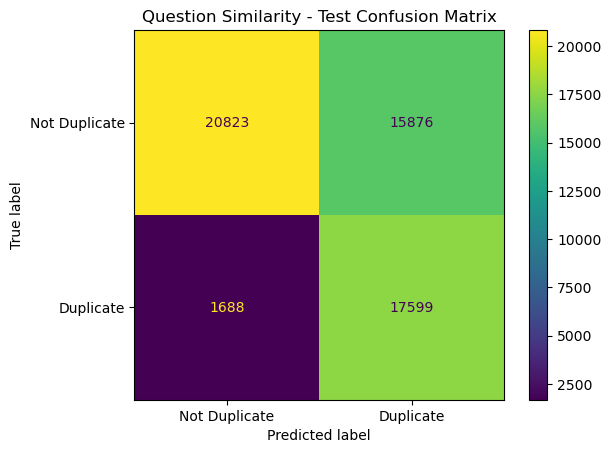

In [23]:
# ============================================================
# CELL 23: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    test_prediction
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,

    display_labels=[
        "Not Duplicate",
        "Duplicate"
    ]
)

disp.plot()

plt.title(
    "Question Similarity - Test Confusion Matrix"
)

plt.show()

In [24]:
# ============================================================
# CELL 24: SAVE MODEL
# ============================================================

MODEL_PATH = (
    MODEL_DIR
    / "question_similarity_xgboost.json"
)

model.save_model(
    str(MODEL_PATH)
)

print(
    "✓ Model saved:"
)

print(
    MODEL_PATH
)

✓ Model saved:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model\question_similarity_xgboost.json


In [25]:
# ============================================================
# CELL 25: SAVE THRESHOLD
# ============================================================

THRESHOLD_PATH = (
    MODEL_DIR
    / "similarity_threshold.pkl"
)

with open(
    THRESHOLD_PATH,
    "wb"
) as file:

    pickle.dump(
        best_threshold,
        file
    )

print(
    "✓ Threshold saved:"
)

print(
    THRESHOLD_PATH
)

✓ Threshold saved:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model\similarity_threshold.pkl


In [26]:
# ============================================================
# CELL 26: SAVE FEATURE NAMES
# ============================================================

FEATURE_NAMES_PATH = (
    MODEL_DIR
    / "feature_names.pkl"
)

with open(
    FEATURE_NAMES_PATH,
    "wb"
) as file:

    pickle.dump(
        feature_names,
        file,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print(
    "✓ Feature names saved."
)

✓ Feature names saved.


In [27]:
# ============================================================
# CELL 27: SAVE METRICS
# ============================================================

METRICS_PATH = (
    MODEL_DIR
    / "model_metrics.json"
)

metrics = {

    "model":
        "XGBoost",

    "number_of_features":
        int(n_features),

    "threshold":
        float(best_threshold),

    "validation": {

        "accuracy":
            float(final_val_accuracy),

        "precision":
            float(final_val_precision),

        "recall":
            float(final_val_recall),

        "f1":
            float(final_val_f1)
    },

    "test": {

        "accuracy":
            float(test_accuracy),

        "precision":
            float(test_precision),

        "recall":
            float(test_recall),

        "f1":
            float(test_f1),

        "roc_auc":
            float(test_auc)
    }
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metrics,
        file,
        indent=4
    )

print(
    "✓ Metrics saved:"
)

print(
    METRICS_PATH
)

✓ Metrics saved:
C:\Users\bimal\OneDrive\Desktop\bibhu sir project\question_similarity_project\model\model_metrics.json


In [28]:
# ============================================================
# CELL 28: FINAL ARTIFACT CHECK
# ============================================================

files_to_check = [

    FEATURE_PATH,

    MODEL_PATH,

    THRESHOLD_PATH,

    FEATURE_NAMES_PATH,

    METRICS_PATH
]

print("=" * 70)
print("FINAL PROJECT ARTIFACTS")
print("=" * 70)

for path in files_to_check:

    if path.exists():

        size = (
            path.stat().st_size
            / (1024 ** 2)
        )

        print(
            f"✓ {path.name:<35}"
            f"{size:.2f} MB"
        )

    else:

        print(
            f"❌ MISSING: {path.name}"
        )

FINAL PROJECT ARTIFACTS
✓ engineered_features.pkl            24.64 MB
✓ question_similarity_xgboost.json   3.91 MB
✓ similarity_threshold.pkl           0.00 MB
✓ feature_names.pkl                  0.00 MB
✓ model_metrics.json                 0.00 MB
